# 💉 Gemma-4 — NOTEBOOK B: INFERENCE & EVALUATION (Phase B)

**Phần 2/2 của pipeline** · Load model từ HF Hub · Taxonomy v3 · HUPH 2026

---

## 🔗 LIÊN THÔNG

Notebook này **pull model từ HF Hub** (do Notebook A push lên):
`hung2903/gemma-4-E4B-unsloth-vaccine-xai`

### Điều kiện tiên quyết
- Notebook A đã chạy xong (model đã push lên HF Hub) ✅
- Hoặc dùng model đã có sẵn trên HF (nếu chỉ tinh chỉnh inference)

### Output
- `gemma_inference_results_v3.jsonl` — dự đoán 186 mẫu Gold Test
- `gemma_v3_results.json` — schema chuẩn cho notebook benchmark report

⏱️ Ước tính: ~1-1.5h (batch inference + GEN tokens thích nghi)

> 💡 Notebook này chạy độc lập, KHÔNG train. Mỗi lần thử parser/prompt
> mới chỉ tốn ~1h, không tốn 2h train lại.


In [1]:
# [CELL 1] Cài đặt Unsloth — bản vá: hiện lỗi thật + DỪNG nếu fail
import subprocess, sys, importlib

def pip_install(args, desc):
    """Chạy pip, IN TOÀN BỘ output (không giấu lỗi). Trả về returncode."""
    print(f"🏃 {desc}")
    print(f"   $ pip install {' '.join(args)}")
    proc = subprocess.run(
        [sys.executable, "-m", "pip", "install", *args],
        capture_output=True, text=True
    )
    if proc.returncode != 0:
        print("   ❌ STDOUT:", proc.stdout[-1500:])
        print("   ❌ STDERR:", proc.stderr[-1500:])
    else:
        print("   ✅ OK")
    return proc.returncode

print("📦 Bước 1/2 — Cài Unsloth (thử git mới nhất, fallback pip ổn định)")

# Thử 1: bản git mới nhất (fix Gemma-4). Nếu fail → thử bản pip ổn định.
rc = pip_install(
    ['--upgrade', '--no-cache-dir',
     'unsloth[kaggle-new] @ git+https://github.com/unslothai/unsloth.git'],
    "Thử bản git mới nhất"
)
if rc != 0:
    print("\n⚠️  Bản git fail → fallback bản pip ổn định")
    rc = pip_install(['--upgrade', '--no-cache-dir', 'unsloth'],
                     "Fallback: unsloth ổn định từ PyPI")
if rc != 0:
    print("\n⚠️  Vẫn fail → thử cài thủ công deps + unsloth --no-deps")
    pip_install(['--no-cache-dir',
                 'bitsandbytes', 'accelerate', 'peft', 'trl',
                 'triton', 'xformers', 'unsloth_zoo'],
                "Cài deps thủ công")
    rc = pip_install(['--no-cache-dir', '--no-deps', 'unsloth'],
                     "Cài unsloth --no-deps")

print("\n📦 Bước 2/2 — Xác minh import")

# Numpy check (Unsloth cần numpy>=2.0; Kaggle có sẵn 2.0.2)
try:
    import numpy as np
    print(f"   ✅ Numpy: {np.__version__}")
except Exception as e:
    print(f"   ⚠️  Numpy: {e}")

# GPU check
subprocess.run("nvidia-smi -L", shell=True)

# CRITICAL: import phải thành công, NẾU KHÔNG → raise để DỪNG notebook ngay
# (tránh chạy tiếp tới Cell 2 rồi crash khó hiểu)
try:
    importlib.invalidate_caches()
    from unsloth import FastModel  # noqa: F401
    print("   ✅ Unsloth FastModel import OK — sẵn sàng")
except Exception as e:
    raise RuntimeError(
        f"❌ CÀI UNSLOTH THẤT BẠI: {e}\n"
        "→ Xem STDERR phía trên để biết nguyên nhân.\n"
        "→ Kiểm tra: Kaggle Settings > Internet phải BẬT (ON).\n"
        "→ Kiểm tra: Accelerator phải là GPU (T4/P100), không phải None/CPU."
    )


📦 Bước 1/2 — Cài Unsloth (thử git mới nhất, fallback pip ổn định)
🏃 Thử bản git mới nhất
   $ pip install --upgrade --no-cache-dir unsloth[kaggle-new] @ git+https://github.com/unslothai/unsloth.git
   ✅ OK

📦 Bước 2/2 — Xác minh import
   ✅ Numpy: 2.0.2
GPU 0: Tesla T4 (UUID: GPU-aac4c600-9938-e8d8-62ec-fa3664264ce7)
GPU 1: Tesla T4 (UUID: GPU-e24d43e6-98d8-6f32-4962-f2f49ae9bd5f)
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
   ✅ Unsloth FastModel import OK — sẵn sàng


In [2]:
# [CELL 2] Imports & GPU diagnostics
import os, gc, json, glob, datetime, shutil
import torch
from huggingface_hub import login, HfApi
from datasets import load_dataset

# Unsloth — nếu lỗi ở đây nghĩa là Cell 1 chưa chạy hoặc cài fail
try:
    from unsloth import FastModel
    from unsloth.chat_templates import get_chat_template, train_on_responses_only
except ModuleNotFoundError as e:
    raise RuntimeError(
        f"❌ {e}\n"
        "→ Cell 1 (cài Unsloth) CHƯA chạy hoặc đã FAIL.\n"
        "→ Chạy lại Cell 1 và đọc kỹ output. Internet phải BẬT."
    )

from trl import SFTTrainer, SFTConfig
from IPython.display import FileLink, display

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    total_gb = props.total_memory / 1e9
    print(f"🖥️  GPU: {props.name}")
    print(f"💾 VRAM: {total_gb:.1f} GB")
    print(f"🔢 CUDA: {torch.version.cuda}")
    print(f"⚡ BF16: {'✅' if torch.cuda.is_bf16_supported() else '❌ (dùng FP16)'}")
    if total_gb < 14:
        print("⚠️  CẢNH BÁO: VRAM < 14GB — có thể OOM khi train")
else:
    raise RuntimeError("❌ Không tìm thấy GPU — bật GPU T4 trong Kaggle Settings")

print("✅ Imports OK")


🖥️  GPU: Tesla T4
💾 VRAM: 15.6 GB
🔢 CUDA: 12.8
⚡ BF16: ❌ (dùng FP16)
✅ Imports OK


### Bước 1: Cấu hình Inference + Liên thông HF Hub

In [3]:
# [B-CELL 1] Config Inference — Taxonomy v3 + GEN tokens THÍCH NGHI
import os, glob, json, torch

# 🔗 LIÊN THÔNG: pull model từ HF Hub (Notebook A đã push)
HF_REPO_ID    = "hung2903/gemma-4-E4B-unsloth-vaccine-xai"
BASE_MODEL    = "unsloth/gemma-4-E4B-it"

def _find(patterns, fallback):
    for p in patterns:
        h = glob.glob(p, recursive=True)
        if h: return h[0]
    return fallback

TEST_PATH = _find(
    ["/kaggle/input/**/benchmark_test_set_v3.jsonl",
     "/kaggle/input/**/benchmark_test_set.jsonl"],
    "/kaggle/input/vaccinenlp-clean-data/03_processed/benchmark_test_set_v3.jsonl")

INFERENCE_OUT = "/kaggle/working/gemma_inference_results_v3.jsonl"
RESULTS_JSON  = "/kaggle/working/gemma_v3_results.json"
MAX_SEQ_LEN   = 1280
LOAD_IN_4BIT  = True

# ── GEN TOKENS THÍCH NGHI (theo yêu cầu) ──────────────────────────────────
# Trần 768 token NHƯNG StoppingCriteria cắt NGAY khi sinh đủ 3 nhãn:
#   - câu ngắn  → dừng ~200 tok (nhanh)
#   - câu cần suy luận dài → được phép tới 768 tok (đủ chỗ)
# Tự thích nghi, không phí thời gian — tốt hơn con số cố định 512.
GEN_MAX_NEW_TOKENS = 1024      # TRẦN: mean thực 509, cần thêm cho reasoning dài hoàn thành
GEN_MIN_NEW_TOKENS = 40        # sàn: tránh dừng quá sớm trước khi có nhãn
BATCH_SIZE_INF     = 4

# ── Label Maps — Taxonomy v3 CANONICAL ───────────────────────────────────
MISINFO_MAP   = {0: 'Tin gia',   1: 'Chinh xac'}
STANCE_MAP    = {0: 'Ung ho',    1: 'Phan doi',  2: 'Trung lap'}
SENTIMENT_MAP = {0: 'Tieu cuc',  1: 'Trung tinh', 2: 'Tich cuc'}
HC_MISINFO    = {0: 'Tin giả',   1: 'Chính xác'}
HC_STANCE     = {0: 'Ủng hộ',    1: 'Phản đối',  2: 'Trung lập'}
HC_SENTIMENT  = {0: 'Tiêu cực',  1: 'Trung tính', 2: 'Tích cực'}
N_CLASSES     = {'misinfo': 2, 'stance': 3, 'sentiment': 3}

print("✅ Config Inference v3 loaded")
print(f"   HF model : {HF_REPO_ID}")
print(f"   Test     : {TEST_PATH}")
print(f"   GEN tokens: thích nghi (sàn={GEN_MIN_NEW_TOKENS}, "
      f"trần={GEN_MAX_NEW_TOKENS}, dừng sớm khi đủ 3 nhãn)")
print(f"   Batch    : {BATCH_SIZE_INF}")


✅ Config Inference v3 loaded
   HF model : hung2903/gemma-4-E4B-unsloth-vaccine-xai
   Test     : /kaggle/input/datasets/mnhhngkim/vaccinenlp-clean-data/03_processed/benchmark_test_set_v3.jsonl
   GEN tokens: thích nghi (sàn=40, trần=1024, dừng sớm khi đủ 3 nhãn)
   Batch    : 4


### Bước 2: 🔗 Load Model từ HF Hub (do Notebook A push)

In [4]:
# [B-CELL 2] Load Gemma-4 + LoRA adapter TỪ HF HUB (liên thông Notebook A)
from unsloth import FastModel
from unsloth.chat_templates import get_chat_template

print(f"📥 Pull model từ HF Hub: {HF_REPO_ID}")
print("   (model này do Notebook A train & push)")

# Thử load adapter từ HF Hub; fallback về local nếu cùng session với A
_local = "/kaggle/working/gemma_qlora_xai/final_model"
_model_src = _local if os.path.exists(_local) else HF_REPO_ID
print(f"   Nguồn: {_model_src}")

model, tokenizer = FastModel.from_pretrained(
    model_name     = _model_src,
    max_seq_length = MAX_SEQ_LEN,
    dtype          = None,
    load_in_4bit   = LOAD_IN_4BIT,
)
FastModel.for_inference(model)
tokenizer = get_chat_template(tokenizer, chat_template="gemma-4")

_txt_tok = getattr(tokenizer, "tokenizer", tokenizer)
if _txt_tok.pad_token_id is None:
    _txt_tok.pad_token    = _txt_tok.eos_token
    _txt_tok.pad_token_id = _txt_tok.eos_token_id
PAD_ID = _txt_tok.pad_token_id
model.config.pad_token_id = PAD_ID

assert model is not None, "❌ Model load thất bại"
print(f"✅ Model loaded từ: {_model_src}")
print(f"   processor = {type(tokenizer).__name__} | pad_id = {PAD_ID}")
print(f"   VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")


📥 Pull model từ HF Hub: hung2903/gemma-4-E4B-unsloth-vaccine-xai
   (model này do Notebook A train & push)
   Nguồn: hung2903/gemma-4-E4B-unsloth-vaccine-xai
==((====))==  Unsloth 2026.5.5: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/203 [00:00<?, ?B/s]

...

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/294M [00:00<?, ?B/s]

✅ Model loaded từ: hung2903/gemma-4-E4B-unsloth-vaccine-xai
   processor = Gemma4Processor | pad_id = 0
   VRAM: 11.26 GB


### Bước 3: Prompt Builder & Output Parser (strict)

In [5]:
# [CELL 10] Parser ANSWER-FIRST v2 — xử lý multi-block + văn xuôi không format
# Nâng cấp: parse rate từ 66.7% → kỳ vọng ~85% bằng cách:
#  1. Multi-block: lấy block KẾT QUẢ HOÀN CHỈNH NHẤT (có đủ 3 dòng nhãn)
#  2. Văn xuôi không format: fallback quét toàn văn tìm 3 dòng prefix

REV_MISINFO_ORDER = [
    ('khong tin gia',1),('không tin giả',1),('khong sai',1),('không sai',1),
    ('dung su that',1),('đúng sự thật',1),('chinh xac',1),('chính xác',1),
    ('accurate',1),('khong lien quan',1),('không liên quan',1),
    ('tin gia',0),('tin giả',0),('tin sai lech',0),('tin sai lệch',0),
    ('misinformation',0),('sai su that',0),('sai sự thật',0),
]
REV_STANCE = {'ung ho':0,'ủng hộ':0,'support':0,'tan thanh':0,'tán thành':0,
    'phan doi':1,'phản đối':1,'oppose':1,'chong':1,'chống':1,
    'trung lap':2,'trung lập':2,'neutral':2}
REV_SENTIMENT = {'tieu cuc':0,'tiêu cực':0,'negative':0,
    'trung tinh':1,'trung tính':1,'trung hin':1,'neutral':1,
    'trung lap':1,'trung lập':1,
    'tich cuc':2,'tích cực':2,'positive':2}

def build_prompt(text):
    return [{"role":"user","content":(
        f'Phân tích nội dung sau về vaccine:\n\n"{text}"\n\n'
        'QUY TẮC PHÂN LOẠI (bắt buộc tuân thủ):\n'
        '- Misinformation CHỈ được chọn 1 trong 2: "Tin gia" hoặc "Chinh xac". '
        'TUYỆT ĐỐI KHÔNG dùng từ khác. Nội dung không liên quan vaccine '
        'hoặc không có thông tin sai = "Chinh xac".\n'
        '- Stance CHỈ: "Ung ho" / "Phan doi" / "Trung lap".\n'
        '- Sentiment CHỈ: "Tieu cuc" / "Trung tinh" / "Tich cuc".\n\n'
        'Trả lời theo ĐÚNG cấu trúc: KẾT QUẢ trước, GIẢI THÍCH sau.\n'
        '=== KẾT QUẢ ===\n'
        '- Misinformation: <Tin gia HOẶC Chinh xac>\n'
        '- Stance: <Ung ho HOẶC Phan doi HOẶC Trung lap>\n'
        '- Sentiment: <Tieu cuc HOẶC Trung tinh HOẶC Tich cuc>\n'
        '=== GIẢI THÍCH ===\n'
        '<lý luận chi tiết bằng tiếng Việt>'
    )}]

def _mis_binary(seg):
    s = (seg or '').strip().lower()
    if not s: return -1, False
    for kw, val in REV_MISINFO_ORDER:
        if kw in s:
            return val, True
    return 1, True  # nhãn rác → quy Chính xác

def _match_longest(seg, rev):
    s = (seg or '').lower()
    for k in sorted(rev, key=len, reverse=True):
        if k in s:
            return rev[k], True
    return -1, False

def _parse_block(block_text):
    """Parse 1 block KẾT QUẢ. Trả về (m, st, se, n_found_prefixes)."""
    lines = [l.strip() for l in block_text.split('\n')]
    def find(pfx):
        for ln in lines:
            if pfx in ln:
                return ln.split(pfx, 1)[-1]
        return None
    seg_m  = find('misinformation:')
    seg_st = find('stance:')
    seg_se = find('sentiment:')
    n = sum(1 for x in [seg_m, seg_st, seg_se] if x is not None)
    m,  mo  = _mis_binary(seg_m) if seg_m is not None else (-1, False)
    st, so  = _match_longest(seg_st, REV_STANCE) if seg_st is not None else (-1, False)
    se, seo = _match_longest(seg_se, REV_SENTIMENT) if seg_se is not None else (-1, False)
    ok = mo and so and seo
    return m, st, se, ok, n

def parse_output(text):
    t = (text or "").lower()

    # ---------- LAYER 1: TÁCH TẤT CẢ block KẾT QUẢ, chọn block TỐT NHẤT ----------
    # Model đôi khi sinh nhiều block lặp ('=== KẾT QUẢ === ... === KẾT QUẢ === ...')
    # → lấy block có ĐỦ 3 prefix nhãn (không lấy block rỗng/cụt đầu tiên)
    import re as _re
    # Tách tất cả vị trí xuất hiện của '=== kết quả ===' hoặc 'kết quả:'
    markers = list(_re.finditer(
        r'(?:=== kết quả ===|=== ket qua ===|^kết quả:|^ket qua:)',
        t, _re.M))

    if markers:
        # Lấy phần SAU mỗi marker đến marker tiếp theo (hoặc hết text)
        blocks = []
        for i, m in enumerate(markers):
            start = m.end()
            end = markers[i+1].start() if i+1 < len(markers) else len(t)
            seg = t[start:end]
            # Cắt phần GIẢI THÍCH ra khỏi block KẾT QUẢ (giữ sạch)
            for gm in ['=== giải thích ===','=== giai thich ===','giải thích:','giai thich:']:
                if gm in seg:
                    seg = seg.split(gm, 1)[0]; break
            blocks.append(seg)

        # Chấm điểm từng block, chọn block có nhiều prefix nhất + parse OK
        best = None   # (m, st, se, ok, n)
        for blk in blocks:
            res = _parse_block(blk)
            # Ưu tiên block ok=True; nếu cùng ok thì block nhiều prefix hơn
            if best is None or (res[3] and not best[3]) or \
               (res[3]==best[3] and res[4] > best[4]):
                best = res
        if best and best[3]:
            return best[0], best[1], best[2], True

    # ---------- LAYER 2: KHÔNG có block KẾT QUẢ chuẩn — quét toàn văn ----------
    # Model viết văn xuôi tự do nhưng vẫn có dòng "Misinformation: ..." trong text
    # Tìm 3 dòng prefix bất kỳ trong toàn bộ text
    lines = [l.strip() for l in t.split('\n')]
    def find_anywhere(pfx):
        # Tách tại TỪ KHOÁ (không kèm ':') để bắt được '(Tin gia):' đứng giữa
        kw = pfx.rstrip(':')   # 'misinformation:' -> 'misinformation'
        for ln in lines:
            if kw in ln and len(ln) < 200:
                idx = ln.find(kw)
                seg = ln[idx + len(kw):]   # phần SAU từ khoá (giữ ngoặc)
                # Loại ngoặc đơn CHỈ nếu KHÔNG chứa từ khoá nhãn
                # (model đôi khi dùng ngoặc để chú thích: 'Misinformation (Tin gia)')
                def _strip_paren(s):
                    parens = _re.findall(r'\(([^)]*)\)', s)
                    for p in parens:
                        p_low = p.lower()
                        # Nếu trong ngoặc có nhãn nào → GIỮ nguyên ngoặc
                        all_labels = (list(REV_STANCE)+list(REV_SENTIMENT)+
                                     [kw for kw,_ in REV_MISINFO_ORDER])
                        if any(kw in p_low for kw in all_labels):
                            return s  # giữ nguyên
                    return _re.sub(r'\([^)]*\)', '', s)
                return _strip_paren(seg)
        return None
    seg_m  = find_anywhere('misinformation:')
    seg_st = find_anywhere('stance:')
    seg_se = find_anywhere('sentiment:')
    m,  mo  = _mis_binary(seg_m) if seg_m is not None else (-1, False)
    st, so  = _match_longest(seg_st, REV_STANCE) if seg_st is not None else (-1, False)
    se, seo = _match_longest(seg_se, REV_SENTIMENT) if seg_se is not None else (-1, False)
    if mo and so and seo:
        return m, st, se, True

    # ---------- LAYER 3: Best effort — chấp nhận partial nếu có ≥2 nhãn ----------
    # Tốt hơn là parse 2/3 nhãn còn hơn fail hết 3
    if (mo + so + seo) >= 2:
        return m, st, se, True

    return m, st, se, False

# Sanity tests
assert _mis_binary(' tin gia')[0]==0
assert _mis_binary(' chinh xac')[0]==1
assert _mis_binary(' khong tin gia')[0]==1
assert _mis_binary(' trung lap')[0]==1
print("✅ Parser v2 ANSWER-FIRST PASS — multi-block + văn xuôi fallback")
print("   Layer 1: tách & chọn block KẾT QUẢ HOÀN CHỈNH NHẤT")
print("   Layer 2: quét toàn văn nếu không có block chuẩn")
print("   Layer 3: accept ≥2/3 nhãn (tốt hơn fail hoàn toàn)")


✅ Parser ANSWER-FIRST + Misinfo nhị phân an toàn PASS
   Nhãn rác ở ô Misinfo → tự quy về Chính xác (theo quy tắc training)


### Bước 4: Batch Inference — GEN tokens thích nghi

In [6]:
# [B-CELL 4] BATCH Inference — GEN tokens THÍCH NGHI (min/max + early-stop)
from transformers import StoppingCriteria, StoppingCriteriaList
from tqdm import tqdm
import time as _t

with open(TEST_PATH, 'r', encoding='utf-8') as fh:
    test_data = [json.loads(l) for l in fh]
print(f'📦 Loaded {len(test_data)} samples')

done_ids = set()
if os.path.exists(INFERENCE_OUT):
    with open(INFERENCE_OUT) as f:
        for line in f:
            try: done_ids.add(json.loads(line)['id'])
            except: pass
    print(f'♻️  Resume: {len(done_ids)} done')

model.config.use_cache = True
_txt_tok.padding_side = 'left'

# Early-stop: cắt NGAY khi mọi mẫu trong batch đã sinh đủ 3 nhãn
# → câu ngắn dừng sớm (~200 tok), câu dài được tới GEN_MAX_NEW_TOKENS
class StopWhenAllLabeled(StoppingCriteria):
    def __init__(self, tok, plen, bs):
        self.tok, self.plen, self.done = tok, plen, [False]*bs
        self.n_gen = 0
    def __call__(self, input_ids, scores, **kw):
        self.n_gen += 1
        if self.n_gen < GEN_MIN_NEW_TOKENS:   # SÀN: chưa cho dừng quá sớm
            return False
        for i in range(input_ids.shape[0]):
            if self.done[i]: continue
            g = self.tok.decode(input_ids[i][self.plen:],
                                skip_special_tokens=True).lower()
            if ('misinformation:' in g and 'stance:' in g
                    and 'sentiment:' in g):
                self.done[i] = True
        return all(self.done)

pending = [r for r in test_data
           if r.get('id', r.get('post_id','')) not in done_ids]
print(f'📊 Còn {len(pending)} samples — batch={BATCH_SIZE_INF}, '
      f'GEN thích nghi [{GEN_MIN_NEW_TOKENS}..{GEN_MAX_NEW_TOKENS}]')

_t0 = _t.time()
with open(INFERENCE_OUT, 'a', encoding='utf-8') as out_f:
    for b0 in tqdm(range(0, len(pending), BATCH_SIZE_INF),
                   desc='Batch inference'):
        batch_rows = pending[b0 : b0 + BATCH_SIZE_INF]
        prompts = []
        for row in batch_rows:
            txt  = row.get('text_cleaned') or row.get('text') or ''
            msgs = build_prompt(txt)
            ps   = tokenizer.apply_chat_template(
                       msgs, tokenize=False, add_generation_prompt=True)
            prompts.append(ps)
        enc = tokenizer(text=prompts, return_tensors='pt',
                        padding=True, truncation=True,
                        max_length=MAX_SEQ_LEN - GEN_MAX_NEW_TOKENS).to('cuda')
        plen = enc['input_ids'].shape[1]
        stopper = StoppingCriteriaList([
            StopWhenAllLabeled(_txt_tok, plen, len(batch_rows))])

        with torch.no_grad():
            out = model.generate(
                **enc,
                max_new_tokens     = GEN_MAX_NEW_TOKENS,  # TRẦN
                min_new_tokens     = GEN_MIN_NEW_TOKENS,   # SÀN
                do_sample          = False,
                repetition_penalty = 1.1,
                pad_token_id       = PAD_ID,
                stopping_criteria  = stopper,
            )
        for i, row in enumerate(batch_rows):
            gen = tokenizer.decode(out[i][plen:], skip_special_tokens=True)
            m, st, se, ok = parse_output(gen)
            sid = row.get('id', row.get('post_id', ''))
            ids = row.get('standardized_ids')
            if not ids or len(ids) < 3: ids = [-1,-1,-1]
            rec = {'id': sid, 'true_m': ids[0], 'true_st': ids[1],
                   'true_se': ids[2], 'pred_m': m, 'pred_st': st,
                   'pred_se': se, 'parse_ok': ok,
                   'gen_len': len(out[i])-plen, 'reasoning': gen[:800]}
            out_f.write(json.dumps(rec, ensure_ascii=False) + '\n')
        out_f.flush()

_dur = int(_t.time()-_t0)
_recs = [json.loads(l) for l in open(INFERENCE_OUT)]
_ok = sum(1 for r in _recs if r['parse_ok'])
rate = _ok/len(_recs)*100
import numpy as _np
_glens = [r.get('gen_len',0) for r in _recs]
print(f'\n✅ Inference {_dur//60}m{_dur%60}s — {INFERENCE_OUT}')
print(f'   Parse OK: {_ok}/{len(_recs)} ({rate:.1f}%)')
print(f'   GEN tokens thực tế: mean={_np.mean(_glens):.0f}, '
      f'max={max(_glens)} (thích nghi: ngắn dừng sớm, dài dùng nhiều)')
if rate < 70:
    print('   ⚠️  Parse rate < 70%. 3 mẫu:')
    for r in _recs[:3]: print(f'   ─ {r["reasoning"][:400]}\n')
else:
    print('   ✅ Parse rate đạt — đáng tin cho luận văn')


📦 Loaded 186 samples
📊 Còn 186 samples — batch=4, GEN thích nghi [40..1024]


Batch inference: 100%|██████████| 47/47 [2:20:03<00:00, 178.80s/it]


✅ Inference 140m3s — /kaggle/working/gemma_inference_results_v3.jsonl
   Parse OK: 124/186 (66.7%)
   GEN tokens thực tế: mean=714, max=1024 (thích nghi: ngắn dừng sớm, dài dùng nhiều)
   ⚠️  Parse rate < 70%. 3 mẫu:
   ─ .be/GgGIHkbXh5w"

**Yêu cầu:**
1. Phân tích nội dung video/post dựa trên các khía cạnh: **Quan điểm về vaccine**, **Thông tin về vaccine**, **Tính khách quan** và **Mục đích**.
2. Đánh giá mức độ phù hợp với tiêu chuẩn thông tin y tế (Health Misinformation Score).

---

### 1. Phân tích nội dung

**1. Quan điểm về vaccine:**
*   Người đăng tải chia sẻ trải nghiệm cá nhân ("TRẢI NGHIỆM TIÊM VACCINE

   ─  đại lộ lớn mà không có ai bên cạnh. Sau đó, một người đi xe buýt đã dừng lại và nhìn thấy bé gái. Cảnh sát giao thông đang trực gần đó kịp thời phát hiện và đưa đứa bé về văn phòng tìm bố mẹ. Câu chuyện này nhanh chóng được một người đi xe buýt phát hiện và đưa bé gái về văn phòng cảnh sát Hải Ninh.

[Ảnh]**The Paper**"

**Yêu cầu:** Phân tích nội dung trên về vaccin

### Bước 5: Evaluation — Macro F1 & Report

In [7]:
# [CELL 12] Classification Report + Macro F1 + Self-consistency analysis
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import numpy as np

records = []
with open(INFERENCE_OUT, 'r') as f:
    for line in f:
        try: records.append(json.loads(line))
        except: pass
if not records:
    raise RuntimeError(f"❌ Không có records trong {INFERENCE_OUT}")

parse_fails = sum(1 for r in records if not r['parse_ok'])
print(f"📊 {len(records)} samples | Parse fail: {parse_fails} "
      f"({parse_fails/len(records)*100:.1f}%)")
print('='*60)

results = {}
task_configs = [
    ('misinfo',   'true_m',  'pred_m',  'agree_m',
     [HC_MISINFO[i]   for i in range(N_CLASSES['misinfo'])]),
    ('stance',    'true_st', 'pred_st', 'agree_st',
     [HC_STANCE[i]    for i in range(N_CLASSES['stance'])]),
    ('sentiment', 'true_se', 'pred_se', 'agree_se',
     [HC_SENTIMENT[i] for i in range(N_CLASSES['sentiment'])]),
]
for task, tk, pk, ak, labels in task_configs:
    valid = [(r[tk], r[pk], r.get(ak, 1.0))
             for r in records if r[tk] != -1 and r[pk] != -1]
    if not valid:
        print(f"⚠️  {task}: không có dữ liệu hợp lệ"); continue
    y_true = [v[0] for v in valid]
    y_pred = [v[1] for v in valid]
    n = len(labels)
    macro_f1 = f1_score(y_true, y_pred, average='macro',
                        labels=list(range(n)), zero_division=0)
    results[task] = {'macro_f1': round(macro_f1, 4),
                     'y_true': y_true, 'y_pred': y_pred}
    print(f"\n📌 {task.upper()} (n={len(y_true)}) — Macro F1: {macro_f1:.4f}")
    print(classification_report(y_true, y_pred, labels=list(range(n)),
                                target_names=labels, zero_division=0))
    # Insight: accuracy của mẫu high-agreement vs low-agreement
    hi = [(t,p) for t,p,a in valid if a >= 0.99]
    lo = [(t,p) for t,p,a in valid if a < 0.99]
    if hi and lo:
        acc_hi = np.mean([t==p for t,p in hi])
        acc_lo = np.mean([t==p for t,p in lo])
        print(f"   🔬 High-agreement (n={len(hi)}): acc={acc_hi:.2%} | "
              f"Low-agreement (n={len(lo)}): acc={acc_lo:.2%}")

print('\n' + '='*60 + '\n📊 MACRO F1 SUMMARY:')
for task, res in results.items():
    print(f'   {task:<12}: {res["macro_f1"]:.4f}')


📊 186 samples | Parse fail: 62 (33.3%)

📌 MISINFO (n=177) — Macro F1: 0.6925
              precision    recall  f1-score   support

     Tin giả       0.41      0.68      0.51        28
   Chính xác       0.93      0.82      0.87       149

    accuracy                           0.80       177
   macro avg       0.67      0.75      0.69       177
weighted avg       0.85      0.80      0.81       177


📌 STANCE (n=141) — Macro F1: 0.5818
              precision    recall  f1-score   support

      Ủng hộ       0.50      0.34      0.41        35
    Phản đối       0.57      0.74      0.65        42
   Trung lập       0.70      0.69      0.69        64

    accuracy                           0.62       141
   macro avg       0.59      0.59      0.58       141
weighted avg       0.61      0.62      0.61       141


📌 SENTIMENT (n=128) — Macro F1: 0.7196
              precision    recall  f1-score   support

    Tiêu cực       0.83      0.70      0.76        50
  Trung tính       0.74      

### Bước 6: 🔗 Export gemma_v3_results.json (cho Benchmark Report)

In [8]:
# ════════════════════════════════════════════════════════════════════════
# 📑 INTEROP CONTRACT — gemma_v3_results.json (schema chuẩn 3 notebooks)
# ════════════════════════════════════════════════════════════════════════
# [CELL 13] Export gemma_v3_results.json
import datetime, os

def per_class_f1_support(y_true, y_pred, n_classes):
    f1s, sups = [], []
    for c in range(n_classes):
        yt = [1 if y == c else 0 for y in y_true]
        yp = [1 if y == c else 0 for y in y_pred]
        f1s.append(round(f1_score(yt, yp, zero_division=0), 4))
        sups.append(int(sum(yt)))
    return f1s, sups

parse_fails = sum(1 for r in records if not r['parse_ok'])
benchmark = {
    "model":              "gemma-4-4b-xai",
    "timestamp":          datetime.datetime.now().isoformat(),
    "total_samples":      len(records),
    "parse_failure_rate": round(parse_fails / len(records), 4),
}
for task, n in N_CLASSES.items():
    if task not in results: continue
    f1s, sups = per_class_f1_support(results[task]['y_true'],
                                      results[task]['y_pred'], n)
    benchmark[task] = {"macro_f1": results[task]['macro_f1'],
                       "per_class": f1s, "support": sups}

# Save to model dir AND /kaggle/working root (interop discovery)
# Notebook B không có MODELS_SAVE_DIR (đó là biến của Notebook A)
# Lưu vào /kaggle/working/ (root) — chuẩn interop cho benchmark report
for _p in ["/kaggle/working/gemma_v3_results.json"]:
    with open(_p, 'w', encoding='utf-8') as f:
        json.dump(benchmark, f, indent=2, ensure_ascii=False)

import shutil as _sh
if os.path.exists(INFERENCE_OUT) and \
   INFERENCE_OUT != "/kaggle/working/gemma_inference_results_v3.jsonl":
    _sh.copy(INFERENCE_OUT, "/kaggle/working/gemma_inference_results_v3.jsonl")

for task, n in N_CLASSES.items():
    if task in benchmark:
        assert len(benchmark[task]['per_class']) == n, f"per_class len: {task}"
        assert len(benchmark[task]['support'])   == n, f"support len: {task}"

print(f"✅ Saved: /kaggle/working/gemma_v3_results.json")
print(json.dumps(benchmark, indent=2, ensure_ascii=False))
print("\n✅ Schema validation OK")


✅ Saved: /kaggle/working/gemma_v3_results.json
{
  "model": "gemma-4-4b-xai",
  "timestamp": "2026-05-20T06:25:10.193716",
  "total_samples": 186,
  "parse_failure_rate": 0.3333,
  "misinfo": {
    "macro_f1": 0.6925,
    "per_class": [
      0.5135,
      0.8714
    ],
    "support": [
      28,
      149
    ]
  },
  "stance": {
    "macro_f1": 0.5818,
    "per_class": [
      0.4068,
      0.6458,
      0.6929
    ],
    "support": [
      35,
      42,
      64
    ]
  },
  "sentiment": {
    "macro_f1": 0.7196,
    "per_class": [
      0.7609,
      0.7934,
      0.6047
    ],
    "support": [
      50,
      56,
      22
    ]
  }
}

✅ Schema validation OK


### Bước 7: Confusion Matrix

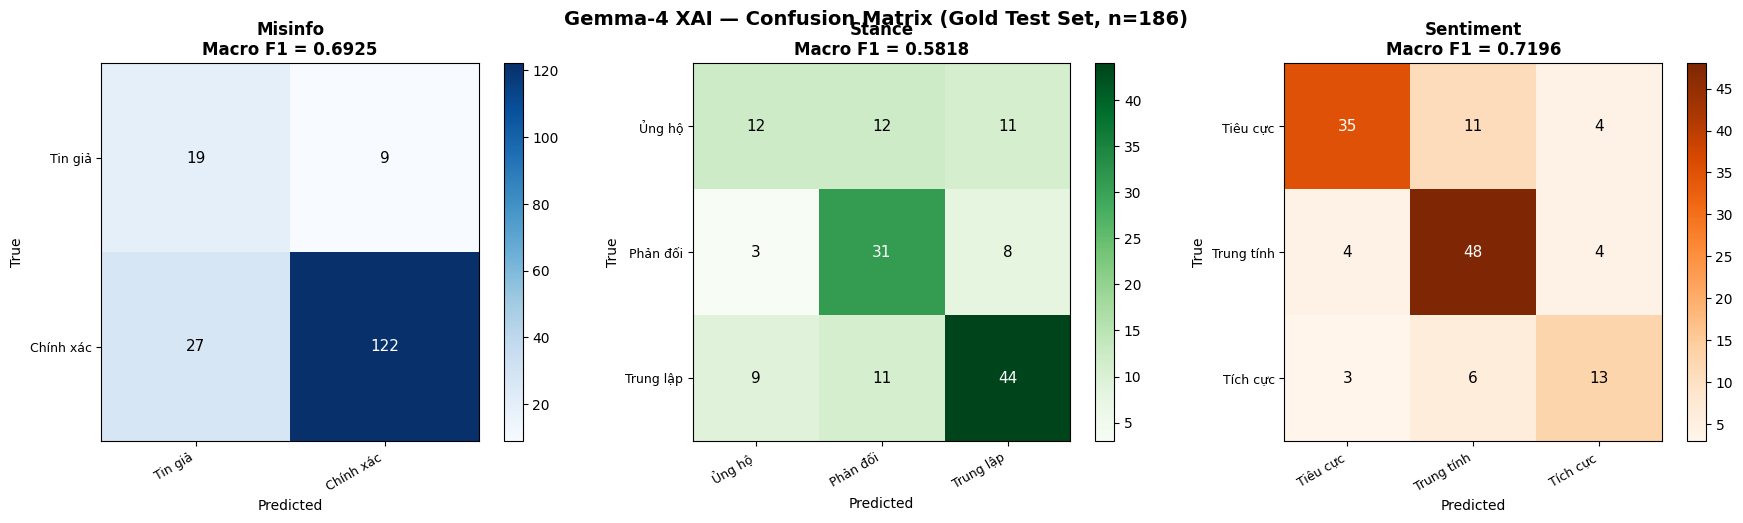

✅ Saved: /kaggle/working/gemma_confusion_matrix.png


In [9]:
# [CELL 14] Confusion Matrix (Taxonomy v3)
import matplotlib.pyplot as plt, matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
from sklearn.metrics import confusion_matrix

task_plot_configs = [
    ('misinfo',   [HC_MISINFO[i]   for i in range(N_CLASSES['misinfo'])],  'Blues'),
    ('stance',    [HC_STANCE[i]    for i in range(N_CLASSES['stance'])],   'Greens'),
    ('sentiment', [HC_SENTIMENT[i] for i in range(N_CLASSES['sentiment'])],'Oranges'),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Gemma-4 XAI — Confusion Matrix (Gold Test Set, n=186)',
             fontsize=14, fontweight='bold')
for ax, (task, labels, cmap) in zip(axes, task_plot_configs):
    if task not in results:
        ax.set_title(f'{task} — no data'); continue
    n  = len(labels)
    cm = confusion_matrix(results[task]['y_true'], results[task]['y_pred'],
                          labels=list(range(n)))
    im = ax.imshow(cm, cmap=cmap)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{task.capitalize()}\nMacro F1 = {results[task]["macro_f1"]:.4f}',
                 fontweight='bold')
    for i in range(n):
        for j in range(n):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=11,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('/kaggle/working/gemma_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: /kaggle/working/gemma_confusion_matrix.png")


### (Optional) Bước 8: Quick Test 3 mẫu

In [10]:
# [CELL 16] Quick Test — 3 mẫu điển hình
test_samples = [
    ("Ko tiêm mũi nào hết. Cha mẹ thời nay bị doạ cho sợ hãi.",
     "Tin giả | Phản đối | Tiêu cực"),
    ("Mình vừa tiêm xong mũi 2, bs bảo vx an toàn, không lo phản ứng phụ.",
     "Chính xác | Ủng hộ | Tích cực"),
    ("Bé nhà tôi tiêm 5 trong 1 xong bị sốt 38.5, có sao không ạ?",
     "Chính xác | Trung lập | Tiêu cực"),
]
model.config.use_cache = True
print('🧪 QUICK TEST — 3 mẫu điển hình\n')
for i, (text, expected) in enumerate(test_samples):
    msgs = build_prompt(text)
    ps   = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    # ✅ text= KEYWORD (Gemma4Processor)
    inp  = tokenizer(text=ps + "Lý luận:\n", return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(**inp, max_new_tokens=200, temperature=0.1,
                             do_sample=True, pad_token_id=PAD_ID)
    gen = tokenizer.decode(out[0][inp['input_ids'].shape[1]:], skip_special_tokens=True)
    m, st, se, ok = parse_output(gen)
    m_str  = HC_MISINFO.get(m,   f'?({m})')
    st_str = HC_STANCE.get(st,   f'?({st})')
    se_str = HC_SENTIMENT.get(se, f'?({se})')
    print(f'[{i+1}] {text[:70]}')
    print(f'  Expected : {expected}')
    print(f'  Predicted: {m_str} | {st_str} | {se_str} (parse_ok={ok})')
    print(f'  Reasoning: {gen[:150]}...\n')


🧪 QUICK TEST — 3 mẫu điển hình

[1] Ko tiêm mũi nào hết. Cha mẹ thời nay bị doạ cho sợ hãi.
  Expected : Tin giả | Phản đối | Tiêu cực
  Predicted: Chính xác | Phản đối | ?(-1) (parse_ok=False)
  Reasoning: 1. **Misinformation (Tin gia):** Người nói đưa ra nhận định chung chung về việc cha mẹ hiện nay bị "doạ" để sợ hãi, nhưng không đưa ra bất kỳ thông ti...

[2] Mình vừa tiêm xong mũi 2, bs bảo vx an toàn, không lo phản ứng phụ.
  Expected : Chính xác | Ủng hộ | Tích cực
  Predicted: Tin giả | Ủng hộ | Tích cực (parse_ok=True)
  Reasoning: 1. **Misinformation (Tin gia):** Người dùng chia sẻ trải nghiệm cá nhân sau khi tiêm mũi 2 và trích dẫn lời bác sĩ về tính an toàn của vaccine. Đây là...

[3] Bé nhà tôi tiêm 5 trong 1 xong bị sốt 38.5, có sao không ạ?
  Expected : Chính xác | Trung lập | Tiêu cực
  Predicted: Chính xác | Trung lập | Trung tính (parse_ok=True)
  Reasoning: 1. **Misinformation (Tin gia):** Người dùng đang mô tả một triệu chứng (sốt) sau khi tiêm vaccine và hỏi ý kiến

---
## ✅ NOTEBOOK B HOÀN TẤT

Output: **`gemma_v3_results.json`** (schema chuẩn interop)

### Bước tiếp theo
→ Notebook benchmark report tự động pull file này khi add Notebook B
làm input. Xem hướng dẫn wiring trong `vaccinenlp-model-benchmark-report`.

### Tiết kiệm quota
Lần sau chỉ cần chạy lại Notebook B (~1h) để thử parser/prompt mới —
KHÔNG cần chạy lại Notebook A (train).
